In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.optimize import minimize, Bounds
from GASModels.simulation.simulator import Simulator
from GASModels.dynamics.dynamics import Dynamics
from GASModels.distributions.gamma_log_link import GammaLogLinkDistribution
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution
from GASModels.distributions.za_gb2_log_link import ZAGB2LogLinkDistribution
from GASModels.distributions.za_gb2_log_link_2 import ZAGB2LogLinkDistribution2

# Test

In [4]:
dynamics = Dynamics(
    distribution=ZAGB2LogLinkDistribution(),
    n=len(xls['precipitation']),
    trend=None,
    seasonality=None,
    harmonics=10,
    period=365.25,
    time_varying_indices=[1],
    fixed_params_indices=[2,3,4],
    args=[0.05, 0.02]
)


In [6]:
def _get_model_parameters(parameter_list):

    array_elems = [
        "km",
        "kg",
        "mu_10",
        *[f"gamma_{h}" for h in range(5)],
        *[f"gamma_star_{h}" for h in range(5)],
    ]
    time_varying_params = dict.fromkeys([1], None)
    for i, param in enumerate([1]):
        param = {"index": param}
        for j, elem in enumerate(array_elems):
            param[elem] = parameter_list[i * len(array_elems) + j]
        time_varying_params[param["index"]] = param

    fixed_params = dict.fromkeys([2,3,4], None)
    for i, param in enumerate([1]):
        param = {"index": param}
        param["value"] = parameter_list[
            len([1]) * len(array_elems) + i
        ]
        fixed_params[param["index"]] = param

    return {"time_vaying_params": time_varying_params, "fixed_params": fixed_params}

In [7]:
_get_model_parameters([1,2,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3])

{'time_vaying_params': {1: {'index': 1,
   'km': 1,
   'kg': 2,
   'mu_10': 1,
   'gamma_0': 2,
   'gamma_1': 3,
   'gamma_2': 4,
   'gamma_3': 5,
   'gamma_4': 6,
   'gamma_star_0': 7,
   'gamma_star_1': 8,
   'gamma_star_2': 9,
   'gamma_star_3': 0,
   'gamma_star_4': 1}},
 'fixed_params': {2: None, 3: None, 4: None, 1: {'index': 1, 'value': 2}}}

## Thesis

In [3]:
xls = pd.read_csv('data/precipitation.csv')
xls = xls.tail(3650)

In [3]:
# Create dynamics object
dynamics = Dynamics(
    distribution=ZAGB2LogLinkDistribution(),
    n=len(xls['precipitation']),
    trend=None,
    seasonality=None,
    harmonics=20,
    period=365.25,
    time_varying_indices=[0],
    fixed_params_indices=[1],
    args=[0.05, 0.02]
)


In [4]:
initial_params = dynamics.get_initial_values(xls['precipitation'])

In [5]:

result = minimize(
    dynamics.objective,
    x0=initial_params,
    args=(xls['precipitation']),
    method='BFGS',
    options={
        'gtol': 1e-3,
        'maxiter': 100,
        'disp': True
    }
)

         Current function value: 2.910079
         Iterations: 4
         Function evaluations: 3095
         Gradient evaluations: 63


c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


In [6]:
result

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 2.9100790474681792
        x: [ 2.071e+01 -1.164e+00 ...  2.028e+02  2.142e+02]
      nit: 4
      jac: [ 3.523e-04 -5.755e-03 ...  1.694e-03  7.228e-03]
 hess_inv: [[ 1.238e+00 -7.065e+00 ...  9.436e-01 -1.202e+01]
            [-7.065e+00  2.106e+02 ... -2.799e+01  3.567e+02]
            ...
            [ 9.436e-01 -2.799e+01 ...  4.739e+00 -4.764e+01]
            [-1.202e+01  3.567e+02 ... -4.764e+01  6.081e+02]]
     nfev: 3095
     njev: 63

In [8]:
dynamics.objective(result['x'], xls['precipitation'][0:730], bounds)

np.float64(2.3963140361132504)

In [7]:
result['x']

array([ 2.07106399e+01, -1.14709198e+00,  1.16531812e-01,  1.23263634e-02,
        1.06901006e-01,  4.71198853e-02,  1.02568159e-01, -7.21026657e-02,
       -8.12059794e-02,  8.98000198e-02, -7.75927483e-02, -1.14773325e-02,
        4.70958529e-02, -5.09225766e-03, -5.18735395e-02,  5.97746067e-02,
        5.27741365e-02,  4.09304626e-02, -6.10397266e-02, -2.03539465e-03,
        7.59601473e-03,  2.11972516e-02, -8.39036818e-02, -5.79179009e-02,
       -4.16830169e-03, -4.65677392e-02,  3.41982822e-02,  3.64710223e-02,
       -6.48065223e-02,  4.11359284e-03, -2.98622828e-02,  9.53042461e-02,
       -4.23838111e-02, -1.43774636e-01,  2.78570407e-02, -2.56537478e-02,
       -1.58601403e-01, -9.98937508e-02, -1.34923327e-01,  1.31740292e-02,
       -1.04555904e-02, -1.80772309e-01,  9.85197256e+00,  3.59480141e+01,
        2.64423736e+01,  1.06905988e+02,  2.02821355e+02,  2.14240917e+02])

In [7]:
result['jac']

array([ 3.52263451e-04, -5.75482845e-03, -5.94854355e-05, -1.42633915e-04,
        1.22159719e-04,  2.02655792e-05, -2.32458115e-05,  1.05381012e-04,
        3.21567059e-05, -1.38878822e-05,  6.73532486e-05,  6.37769699e-05,
        1.27524137e-04,  2.11596489e-05, -2.36034393e-05,  4.38094139e-05,
        6.58333302e-05,  2.46167183e-05,  2.00092793e-04, -4.22894955e-05,
        1.39713287e-04, -1.15424395e-04, -3.69548798e-04, -1.39176846e-05,
       -1.48355961e-04, -1.09583139e-04, -3.45706940e-06,  1.32113695e-04,
        1.80959702e-04, -7.34925270e-05,  9.19699669e-05,  3.41534615e-05,
        6.07669353e-05,  2.89082527e-05, -1.73300505e-04, -5.79655170e-05,
        5.88595867e-05, -2.65240669e-05,  6.79492950e-05,  3.57627869e-07,
        7.07507133e-05,  6.80088997e-05,  1.47432089e-04,  3.75849009e-03,
        3.42994928e-03,  1.27249956e-03,  1.69441104e-03,  7.22754002e-03])

In [8]:
fis = result['x']

In [9]:
def fit_in_sample(params, y):
    gamma = np.zeros(20)
    gamma_star = np.zeros(20)

    km = params[0] / 1000
    kg = params[1] / 1000

    for i in range(20):
        gamma[i] = params[i + 2] / 100
        gamma_star[i] = params[i + 2 + 20] / 100

    mu0 = params[20 * 2 + 2] / 100
    delta_0 = params[20 * 2 + 3] / 100
    delta_1 = params[20 * 2 + 4] / 100
    gamma_ = params[20 * 2 + 5] / 100
    xi = params[20 * 2 + 6] / 100
    zeta = params[20 * 2 + 7] / 100

    # gamma_ = params[self.harmonics * 2 + 3] / 100
    # xi = params[self.harmonics * 2 + 4] / 100
    # zeta = params[self.harmonics * 2 + 5] / 100

    level = np.zeros(len(xls['precipitation']))
    seas = np.zeros(len(xls['precipitation']))

    mu = mu0
    fit_in_sample = np.zeros(len(xls['precipitation']))
    mean_gb2 = np.zeros(len(xls['precipitation']))
    pi = np.zeros(len(xls['precipitation']))

    for t in range(len(xls['precipitation'])):
        phi = mu + np.sum(gamma)
        level[t] = mu
        seas[t] = np.sum(gamma)

        score = ZAGB2LogLinkDistribution().score(
            y[t],
            delta_0=delta_0,
            delta_1=delta_1,
            phi=phi,
            gamma=gamma_,
            xi=xi,
            zeta=zeta,
        )[0]
        mean_gb2[t], fit_in_sample[t] = ZAGB2LogLinkDistribution().mean(
            delta_0=delta_0,
            delta_1=delta_1,
            phi=phi,
            gamma=gamma_,
            xi=xi,
            zeta=zeta,
        )
        mu = mu + km * score
        pi[t] = np.exp(delta_0 + delta_1 * phi) / (
            1 + np.exp(delta_0 + delta_1 * phi)
        )

        for i in range(20):
            lambda_i = (2 * np.pi * (i + 1)) / 365.25
            gamma_t1 = (
                np.cos(lambda_i) * gamma[i]
                + np.sin(lambda_i) * gamma_star[i]
                + kg * score
            )
            gamma_start_t1 = (
                np.cos(lambda_i) * gamma_star[i]
                - np.sin(lambda_i) * gamma[i]
                + kg * score
            )
            gamma[i] = gamma_t1
            gamma_star[i] = gamma_start_t1

    return mean_gb2, fit_in_sample, pi, level, seas

In [9]:
mean_gb2, y, pi, level, seas = dynamics.fit_in_sample(fis, xls['precipitation'].values)

In [11]:
df = pd.DataFrame(
    {
        'mean_gb2': mean_gb2, 
        'pi': pi, 
        '1-step-ahead': y, 
        'orig': xls['precipitation'],
        'level': level,
        'seas': seas
    }
)
dates = pd.date_range(start='2008-01-01', periods=len(df), freq='D')
df.index = dates

In [12]:
df

,mean_gb2,pi,1-step-ahead,orig,level,seas
2008-01-01,1.123972,0.614752,0.690964,0.0,0.098151,0.002821
2008-01-02,1.055739,0.609072,0.643021,0.0,0.093459,-0.055115
2008-01-03,0.983040,0.602565,0.592346,0.0,0.088811,-0.121813
2008-01-04,0.910286,0.595512,0.542086,0.0,0.084212,-0.194105
2008-01-05,0.841164,0.588226,0.494795,14.2,0.079667,-0.268532
...,...,...,...,...,...,...
2024-09-30,2.734915,0.691459,1.891081,10.2,1.136185,-0.145981
2024-10-01,2.963008,0.697947,2.068023,9.6,1.163216,-0.092907
2024-10-02,3.573769,0.712820,2.547454,0.0,1.188678,0.069046
2024-10-03,3.219313,0.704585,2.268279,0.0,1.183238,-0.029966


In [12]:
y

array([1.33538969, 1.1401691 , 0.95316256, ..., 6.19165864, 4.88832743,
       3.83533775], shape=(6122,))

Text(0, 0.5, 'Precipitation - mm')

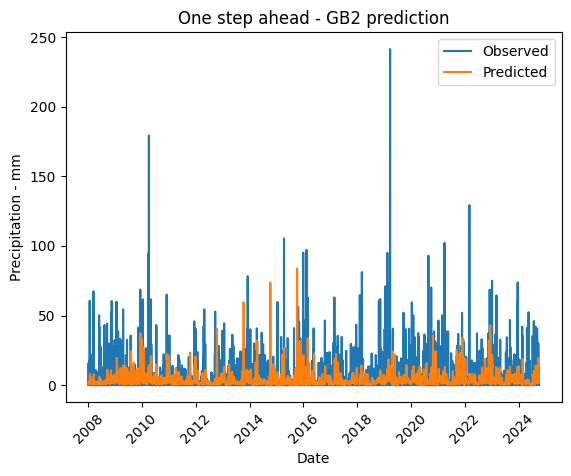

In [13]:
plt.plot(df['orig'])
plt.plot(df['1-step-ahead'])
plt.title("One step ahead - GB2 prediction")
plt.legend(["Observed", "Predicted"])
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Precipitation - mm")

In [10]:
pit = dynamics.pit(fis, xls['precipitation'].values)

In [20]:
gt0 = pit[df['orig'] > 0]

(array([2145.,  403.,   95.,   90.,   84.,  106.,  120.,  107.,  192.,
         308.]),
 array([0.3104493 , 0.3793693 , 0.4482893 , 0.5172093 , 0.58612929,
        0.65504929, 0.72396929, 0.79288928, 0.86180928, 0.93072928,
        0.99964928]),
 <BarContainer object of 10 artists>)

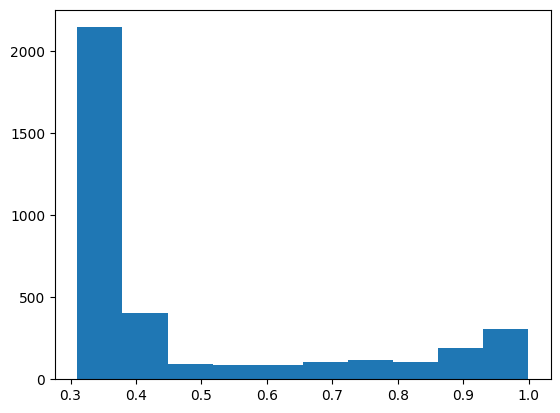

In [11]:
plt.hist(pit)

In [6]:
xls.index = pd.date_range(start="2008-01-01", periods=len(xls), freq="D")

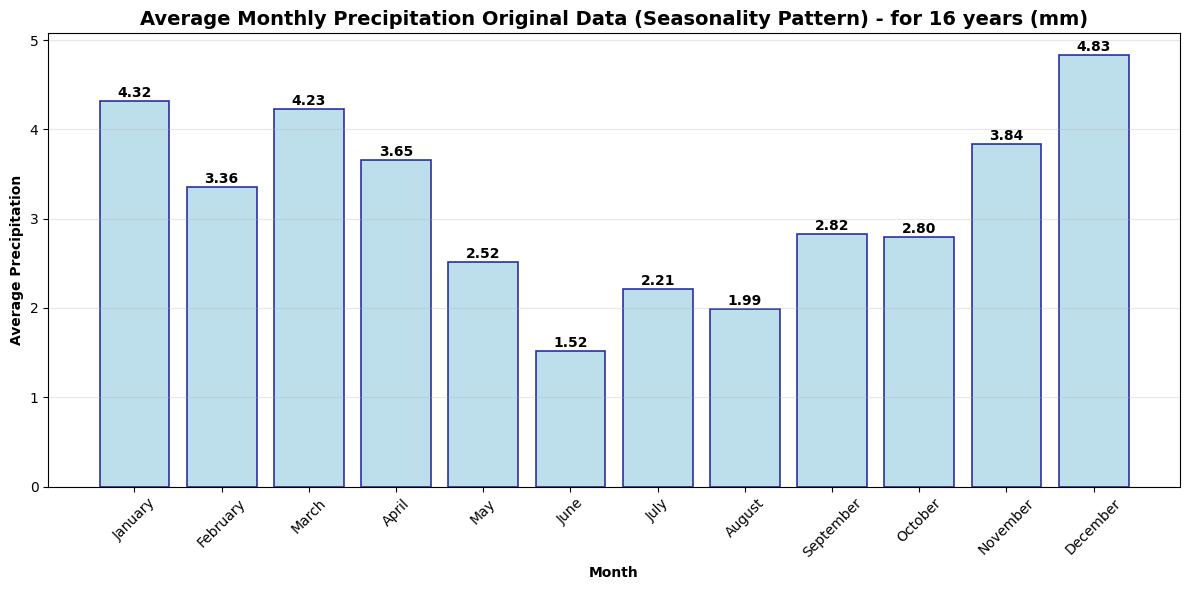

In [10]:
# Calculate monthly averages
monthly_avg = xls.groupby(xls.index.month)['precipitation'].mean()

# Plot with month names
import calendar
month_names = [calendar.month_name[i] for i in monthly_avg.index]

plt.figure(figsize=(12, 6))
bars = plt.bar(month_names, monthly_avg.values, color='lightblue', edgecolor='darkblue', linewidth=1.2, alpha=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('Average Monthly Precipitation Original Data (Seasonality Pattern) - for 16 years (mm)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Average Precipitation', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [26]:
y_fit

,precipitation - prediction
2008-01-01,8.665776
2008-01-02,8.629050
2008-01-03,8.575292
2008-01-04,8.508283
2008-01-05,8.432872
...,...
2017-12-24,4.535397
2017-12-25,4.603260
2017-12-26,4.573767
2017-12-27,4.669546


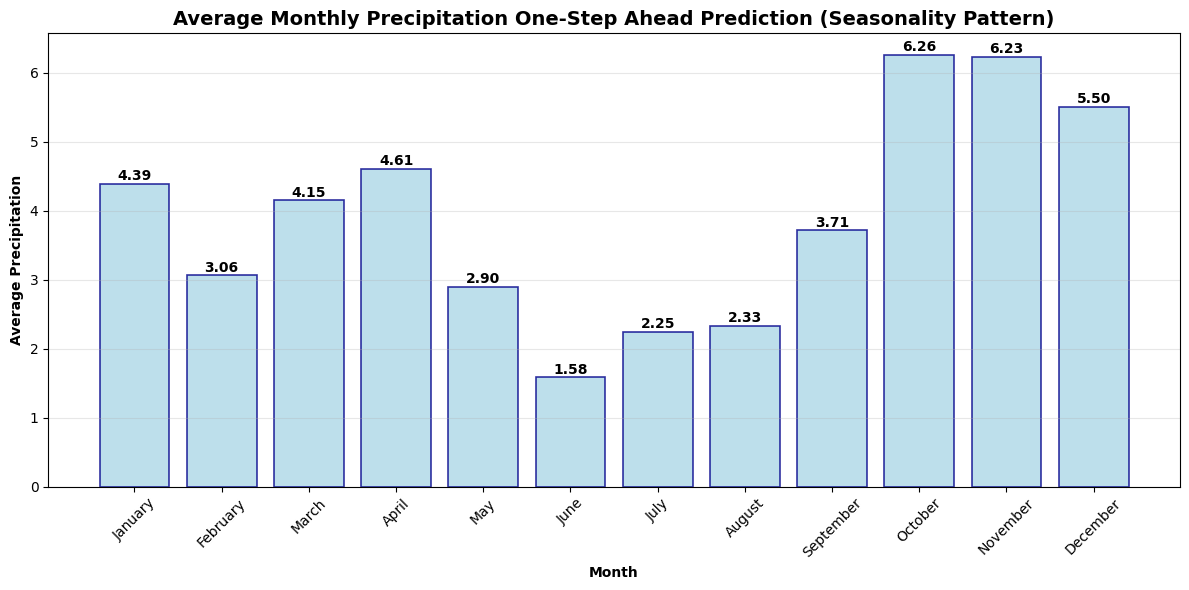

In [20]:
# Calculate monthly averages
monthly_avg = y_fit.groupby(y_fit.index.month)['precipitation - prediction'].mean()

# Plot with month names
import calendar
month_names = [calendar.month_name[i] for i in monthly_avg.index]

plt.figure(figsize=(12, 6))
bars = plt.bar(month_names, monthly_avg.values, color='lightblue', edgecolor='darkblue', linewidth=1.2, alpha=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('Average Monthly Precipitation One-Step Ahead Prediction (Seasonality Pattern)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Average Precipitation', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [16]:
quant = dynamics.get_quantile_residuals(pit)

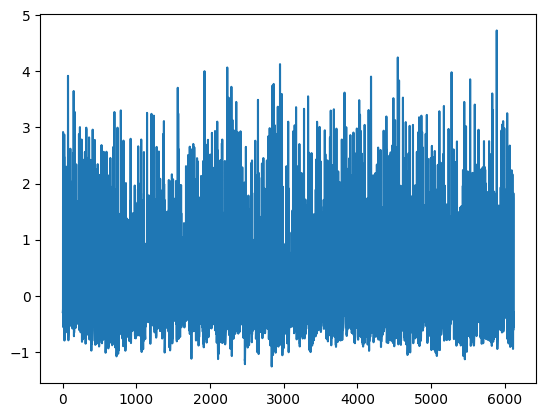

In [17]:
plt.plot(quant)

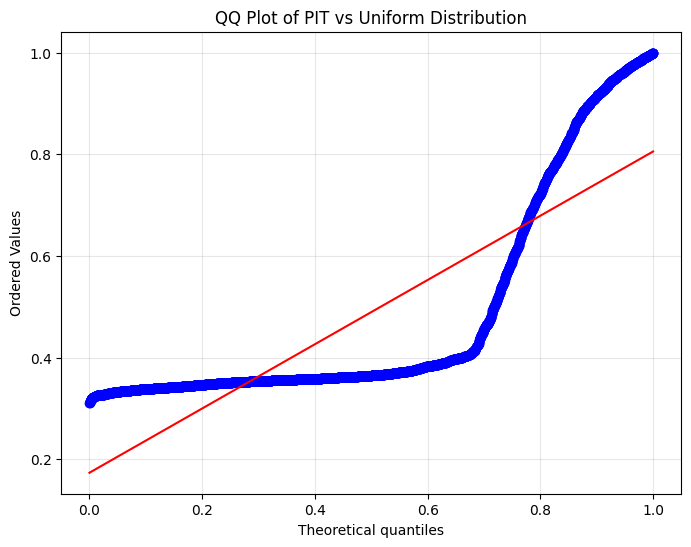

In [13]:
# Create QQ plot
plt.figure(figsize=(8, 6))
stats.probplot(pit, dist="uniform", plot=plt)
plt.title('QQ Plot of PIT vs Uniform Distribution')
plt.grid(True, alpha=0.3)
plt.show()

First 20 lags:
    lag       acf  conf_lower  conf_upper
0     0  1.000000    1.000000    1.000000
1     1  0.355556    0.330507    0.380606
2     2  0.095039    0.067001    0.123077
3     3 -0.011915   -0.040154    0.016325
4     4 -0.040476   -0.068719   -0.012233
5     5 -0.050082   -0.078361   -0.021803
6     6 -0.065438   -0.093773   -0.037103
7     7 -0.085522   -0.113951   -0.057093
8     8 -0.069749   -0.098339   -0.041158
9     9 -0.071266   -0.099963   -0.042569
10   10 -0.064471   -0.093279   -0.035664
11   11 -0.035025   -0.063923   -0.006127
12   12 -0.023818   -0.052743    0.005106
13   13 -0.025320   -0.054257    0.003617
14   14  0.002235   -0.026716    0.031186
15   15  0.045555    0.016604    0.074506
16   16  0.063179    0.034183    0.092175
17   17  0.078883    0.049800    0.107965
18   18  0.055374    0.026158    0.084590
19   19  0.047279    0.017997    0.076561

Lags with ACF > 0.1: 2
   lag       acf
0    0  1.000000
1    1  0.355556

Lags with ACF < -0.1: 0
Emp

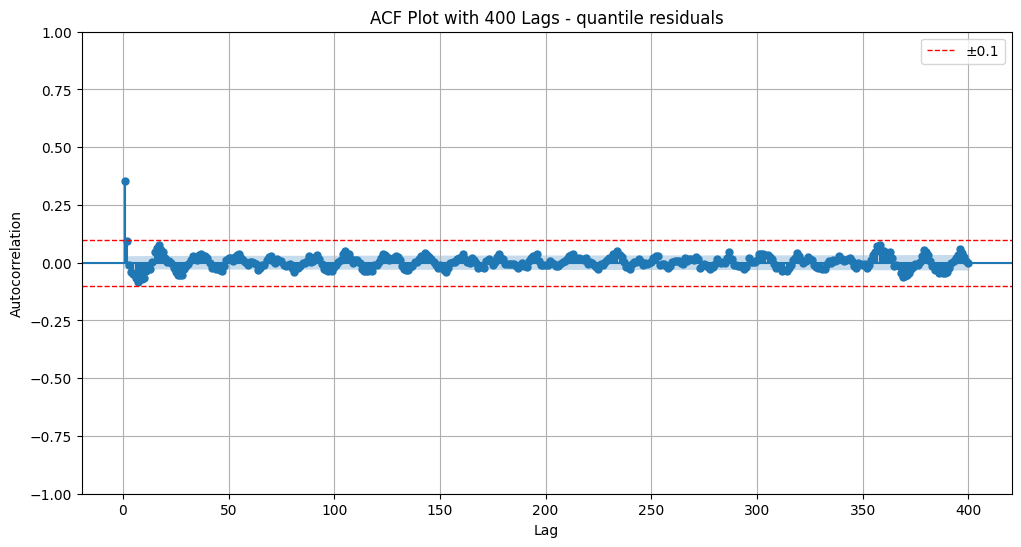

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Calculate ACF values directly
acf_values, confint = acf(quant, nlags=400, alpha=0.05, fft=False)

# Create a DataFrame with lag numbers and ACF values
acf_df = pd.DataFrame({
    'lag': np.arange(0, len(acf_values)),
    'acf': acf_values,
    'conf_lower': confint[:, 0],
    'conf_upper': confint[:, 1]
})

# Display first few lags
print("First 20 lags:")
print(acf_df.head(20))

# Find lags where ACF exceeds certain thresholds
significant_lags_positive = acf_df[acf_df['acf'] > 0.1]
significant_lags_negative = acf_df[acf_df['acf'] < -0.1]

print(f"\nLags with ACF > 0.1: {len(significant_lags_positive)}")
print(significant_lags_positive[['lag', 'acf']].head(10))

print(f"\nLags with ACF < -0.1: {len(significant_lags_negative)}")
print(significant_lags_negative[['lag', 'acf']].head(10))

# You can also get specific lag values
print(f"\nACF at lag 1: {acf_values[1]:.4f}")
print(f"ACF at lag 5: {acf_values[5]:.4f}")
print(f"ACF at lag 10: {acf_values[10]:.4f}")

# Plot (same as your original code)
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(quant, lags=400, ax=ax, alpha=0.05, zero=False)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='±0.1')
ax.axhline(y=-0.1, color='red', linestyle='--', linewidth=1)
plt.title('ACF Plot with 400 Lags - quantile residuals')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()
plt.show()

First 20 lags:
    lag       acf  conf_lower  conf_upper
0     0  1.000000    1.000000    1.000000
1     1  0.211924    0.186875    0.236974
2     2  0.035216    0.009066    0.061367
3     3  0.002216   -0.023964    0.028396
4     4 -0.010058   -0.036239    0.016122
5     5  0.022586   -0.003597    0.048769
6     6  0.039233    0.013038    0.065428
7     7  0.013252   -0.012980    0.039484
8     8  0.040248    0.014012    0.066484
9     9  0.008554   -0.017721    0.034829
10   10  0.002803   -0.023473    0.029080
11   11  0.022885   -0.003392    0.049162
12   12  0.011653   -0.014636    0.037943
13   13 -0.002695   -0.028988    0.023597
14   14  0.015322   -0.010970    0.041615
15   15  0.012144   -0.014154    0.038442
16   16  0.021176   -0.005126    0.047477
17   17  0.013776   -0.012536    0.040089
18   18  0.029818    0.003501    0.056135
19   19  0.028934    0.002596    0.055272

Lags with ACF > 0.1: 2
   lag       acf
0    0  1.000000
1    1  0.211924

Lags with ACF < -0.1: 0
Emp

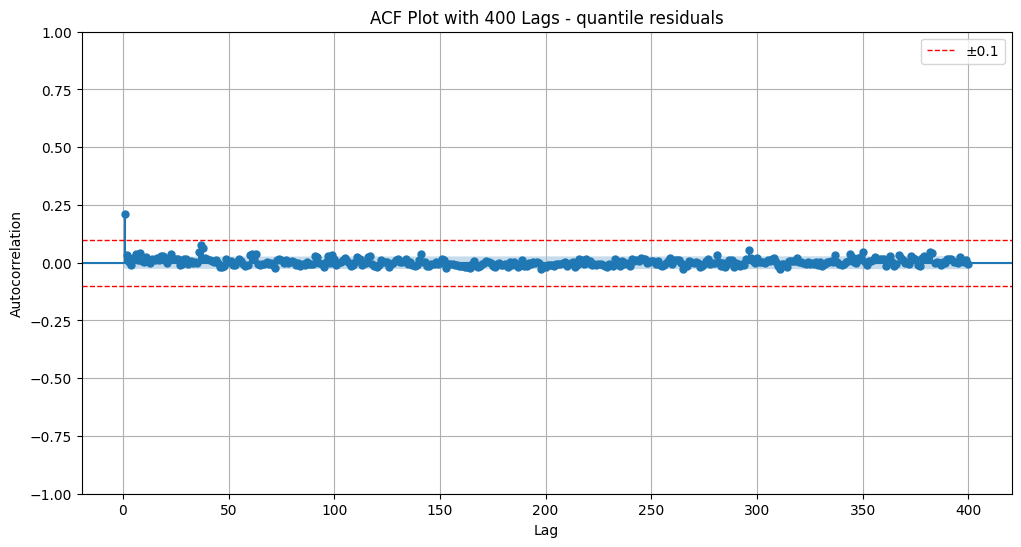

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Calculate ACF values directly
acf_values, confint = acf(df['orig'].values, nlags=400, alpha=0.05, fft=False)

# Create a DataFrame with lag numbers and ACF values
acf_df = pd.DataFrame({
    'lag': np.arange(0, len(acf_values)),
    'acf': acf_values,
    'conf_lower': confint[:, 0],
    'conf_upper': confint[:, 1]
})

# Display first few lags
print("First 20 lags:")
print(acf_df.head(20))

# Find lags where ACF exceeds certain thresholds
significant_lags_positive = acf_df[acf_df['acf'] > 0.1]
significant_lags_negative = acf_df[acf_df['acf'] < -0.1]

print(f"\nLags with ACF > 0.1: {len(significant_lags_positive)}")
print(significant_lags_positive[['lag', 'acf']].head(10))

print(f"\nLags with ACF < -0.1: {len(significant_lags_negative)}")
print(significant_lags_negative[['lag', 'acf']].head(10))

# You can also get specific lag values
print(f"\nACF at lag 1: {acf_values[1]:.4f}")
print(f"ACF at lag 5: {acf_values[5]:.4f}")
print(f"ACF at lag 10: {acf_values[10]:.4f}")

# Plot (same as your original code)
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(df['orig'].values, lags=400, ax=ax, alpha=0.05, zero=False)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='±0.1')
ax.axhline(y=-0.1, color='red', linestyle='--', linewidth=1)
plt.title('ACF Plot with 400 Lags - quantile residuals')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()
plt.show()

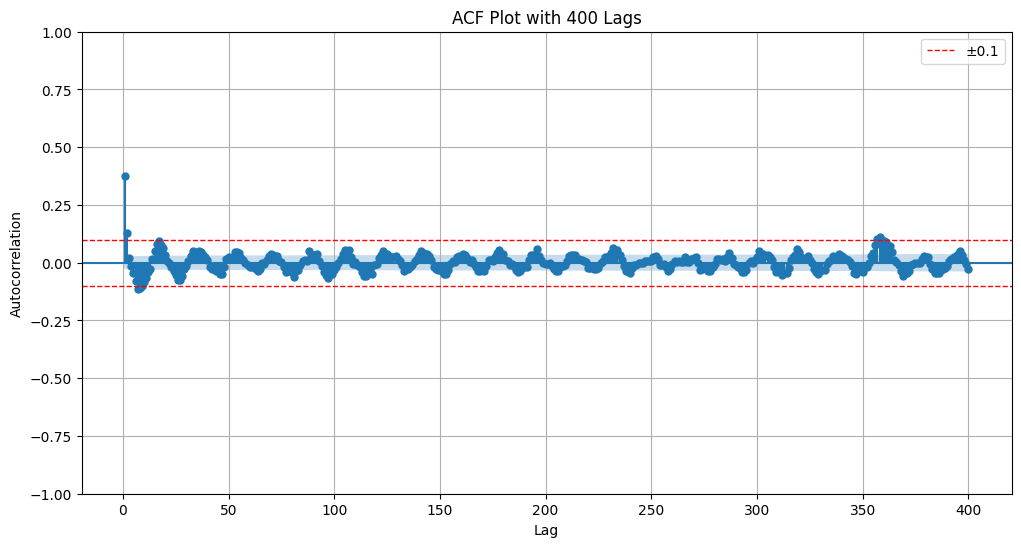

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Assuming 'quant' is your time series data
fig, ax = plt.subplots(figsize=(12, 6))

# Plot ACF without lag 0 by starting from lag 1
plot_acf(pit, lags=400, ax=ax, alpha=0.05, zero=False)

# Add red horizontal lines at -0.1 and 0.1
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='±0.1')
ax.axhline(y=-0.1, color='red', linestyle='--', linewidth=1)

plt.title('ACF Plot with 400 Lags')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()
plt.show()

In [21]:
from scipy.special import digamma, polygamma, beta

In [22]:
def variance(delta_0, delta_1, phi, gamma, xi, zeta):

    # Numerical stability for pi
    linear_comb = delta_0 + delta_1 * phi
    pi = np.exp(linear_comb) / (1 + np.exp(linear_comb))

    # GB2 component moments
    ex = (
        np.exp(phi)
        * beta(np.exp(xi) + np.exp(gamma), np.exp(zeta) - np.exp(gamma))
        / beta(np.exp(xi), np.exp(zeta))
    )

    ex2 = (
        np.exp(phi) ** 2
        * beta(np.exp(xi) + 2 * np.exp(gamma), np.exp(zeta) - 2 * np.exp(gamma))
        / beta(np.exp(xi), np.exp(zeta))
    )

    # Variance of GB2 component
    var_fy = ex2 - ex**2

    # CORRECTED: Zero-inflated mixture variance formula
    # Var(y) = π * σ₁² + π(1-π) * μ₁²
    variance = pi * var_fy + pi * (1 - pi) * ex**2

    return variance

In [103]:
delta_0

NameError: name 'delta_0' is not defined

In [36]:
erro = []
for i in range(730):
    erro.append((df['orig'].values[i] - df['1-step-ahead'].values[i])/variance(delta_0, delta_1, phis[i], gamma_, xi, zeta))

In [37]:
erro

[np.float64(-6.349548403947708e-05),
 np.float64(-0.00012374000527188187),
 np.float64(-0.00012034697546748313),
 np.float64(9.983366259387002e-05),
 np.float64(-0.0003838228168860707),
 np.float64(-7.883293156589672e-05),
 np.float64(-1.0248136660540878e-05),
 np.float64(1.012947598751217e-06),
 np.float64(-2.7520456147102696e-05),
 np.float64(-3.42867221061998e-05),
 np.float64(-4.6767027298805775e-05),
 np.float64(-6.839743519904247e-05),
 np.float64(-0.00010446146709942254),
 np.float64(-0.0001617342974880499),
 np.float64(-0.0002463031554306134),
 np.float64(0.0003490927958134686),
 np.float64(-0.00015693629529937826),
 np.float64(-9.092442997161948e-05),
 np.float64(5.46221199294889e-05),
 np.float64(-1.502135880661323e-05),
 np.float64(-1.421896010454099e-05),
 np.float64(-2.8233043587394005e-06),
 np.float64(-1.6378863202135713e-06),
 np.float64(-1.0658242760120084e-06),
 np.float64(-1.0819738792816846e-06),
 np.float64(-5.166580678962241e-06),
 np.float64(-9.509225827372032e-0

In [ ]:
(df['orig'] - df['1-step-ahead']

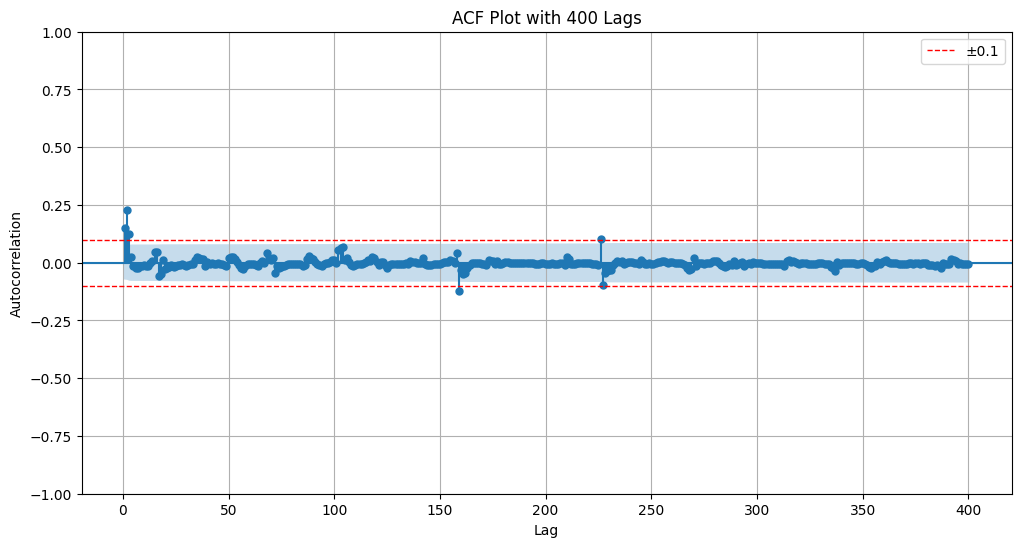

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Assuming 'quant' is your time series data
fig, ax = plt.subplots(figsize=(12, 6))

# Plot ACF without lag 0 by starting from lag 1
plot_acf(erro, lags=400, ax=ax, alpha=0.05, zero=False)

# Add red horizontal lines at -0.1 and 0.1
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='±0.1')
ax.axhline(y=-0.1, color='red', linestyle='--', linewidth=1)

plt.title('ACF Plot with 400 Lags')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()
plt.show()

In [91]:
from statsmodels.tsa.stattools import acf

# Calculate ACF values for 400 lags
acf_values = acf(quant, nlags=400, fft=True)

print(f"ACF values shape: {acf_values.shape}")
print(f"First 10 ACF values: {acf_values[:10]}")

ACF values shape: (401,)
First 10 ACF values: [ 1.          0.44893416  0.21865644  0.08302788  0.02220808 -0.01778041
 -0.06171926 -0.09630676 -0.09932982 -0.12114146]


In [31]:
gamma = np.zeros(20)
gamma_star = np.zeros(20)

km = fis[0] / 1000
kg = fis[1] / 1000

for i in range(20):
    gamma[i] = fis[i + 2] / 100
    gamma_star[i] = fis[i + 2 + 20] / 100

mu0 = fis[20 * 2 + 2] / 100
delta_0 = fis[20 * 2 + 3] / 100
delta_1 = fis[20 * 2 + 4] / 100
gamma_ = fis[20 * 2 + 5] / 100
xi = fis[20 * 2 + 6] / 100
zeta = fis[20 * 2 + 7] / 100

In [108]:
print(f"km: {km}, kg: {kg}, gamma: {gamma}, gamma_star: {gamma_star}, mu0: {mu0}, delta_0: {delta_0}, delta_1: {delta_1}, gamma_: {gamma_}, xi: {xi}, zeta: {zeta}")

km: 0.027732667174791815, kg: 0.025083341136487785, gamma: [-3.79455482e-04  1.86388146e-03 -4.43999848e-03 -7.14911793e-05
 -3.85385833e-03 -5.58083541e-03  4.41618619e-03  9.10345797e-04
 -3.42414405e-03  4.83570340e-03 -3.47302142e-03 -1.39419925e-03
 -4.50474192e-03  1.57558295e-03  3.72771830e-03  4.06006953e-03
 -4.81564088e-03 -2.20429833e-04 -3.20589541e-04 -6.71878903e-03], gamma_star: [ 1.29579107e-03 -6.22904740e-04 -9.89701123e-05 -2.59738808e-05
  5.59837944e-03 -6.48319855e-03 -1.13260895e-03  4.78877680e-03
 -2.29980867e-03 -3.42529068e-04 -4.52909116e-03 -9.09215202e-03
  6.14044215e-03  2.80031999e-03 -6.57430984e-03 -3.13638400e-03
 -1.04575259e-02 -6.88783059e-03 -4.35493164e-03 -6.77868100e-03], mu0: 0.09629200261292464, delta_0: 0.12915512435930307, delta_1: 0.5048662006269842, gamma_: 1.2869986482123794, xi: 2.385101502801308, zeta: 1.6330047293948575


In [61]:
(xls['precipitation'] == 0).sum()

np.int64(3769)

In [33]:
def fit_in_sample(params, y, size):
    gamma = np.zeros(20)
    gamma_star = np.zeros(20)

    km = params[0] / 1000
    kg = params[1] / 1000

    for i in range(20):
        gamma[i] = params[i + 2] / 100
        gamma_star[i] = params[i + 2 + 20] / 100

    mu0 = params[20 * 2 + 2] / 100
    delta_0 = params[20 * 2 + 3] / 100
    delta_1 = params[20 * 2 + 4] / 100
    gamma_ = params[20 * 2 + 5] / 100
    xi = params[20 * 2 + 6] / 100
    zeta = params[20 * 2 + 7] / 100

    mu = mu0
    fit_in_sample = np.zeros(size)
    mean_gb2 = np.zeros(size)
    pi = np.zeros(size)
    gammas = np.zeros(size)
    phis = np.zeros(size)

    for t in range(size):
        phi = mu + np.sum(gamma)
        phis[t] = phi
        gammas[t] = np.exp(np.sum(gamma))

        score = ZAGB2LogLinkDistribution().score(
            y[t],
            delta_0=delta_0,
            delta_1=delta_1,
            phi=phi,
            gamma=gamma_,
            xi=xi,
            zeta=zeta,
        )[0]
        mean_gb2[t], fit_in_sample[t] = ZAGB2LogLinkDistribution().mean(
            delta_0=delta_0,
            delta_1=delta_1,
            phi=phi,
            gamma=gamma_,
            xi=xi,
            zeta=zeta,
        )
        mu += km * score
        pi[t] = np.exp(delta_0 + delta_1 * phi) / (
            1 + np.exp(delta_0 + delta_1 * phi)
        )

        for i in range(20):
            lambda_i = (2 * np.pi * (i + 1)) / 365.25
            gamma_t1 = (
                np.cos(lambda_i) * gamma[i]
                + np.sin(lambda_i) * gamma_star[i]
                + kg * score
            )
            gamma_start_t1 = (
                np.cos(lambda_i) * gamma_star[i]
                - np.sin(lambda_i) * gamma[i]
                + kg * score
            )
            gamma[i] = gamma_t1
            gamma_star[i] = gamma_start_t1

    return mean_gb2, fit_in_sample, pi, gammas, phis

In [34]:
m, f, pi, gammas, phis = fit_in_sample(fis, xls['precipitation'], 1825)

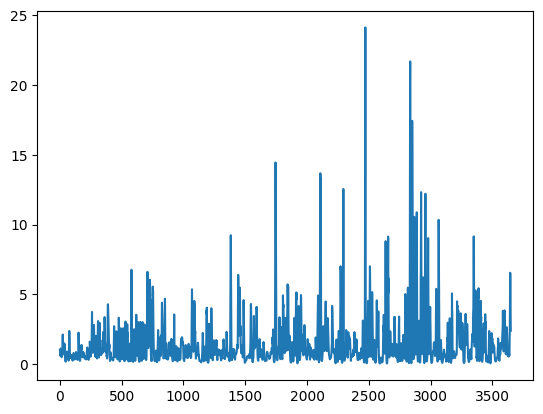

In [21]:
plt.plot(gammas)

In [26]:
y_fit = pd.DataFrame(gammas, index = dates, columns = ['gamma'])

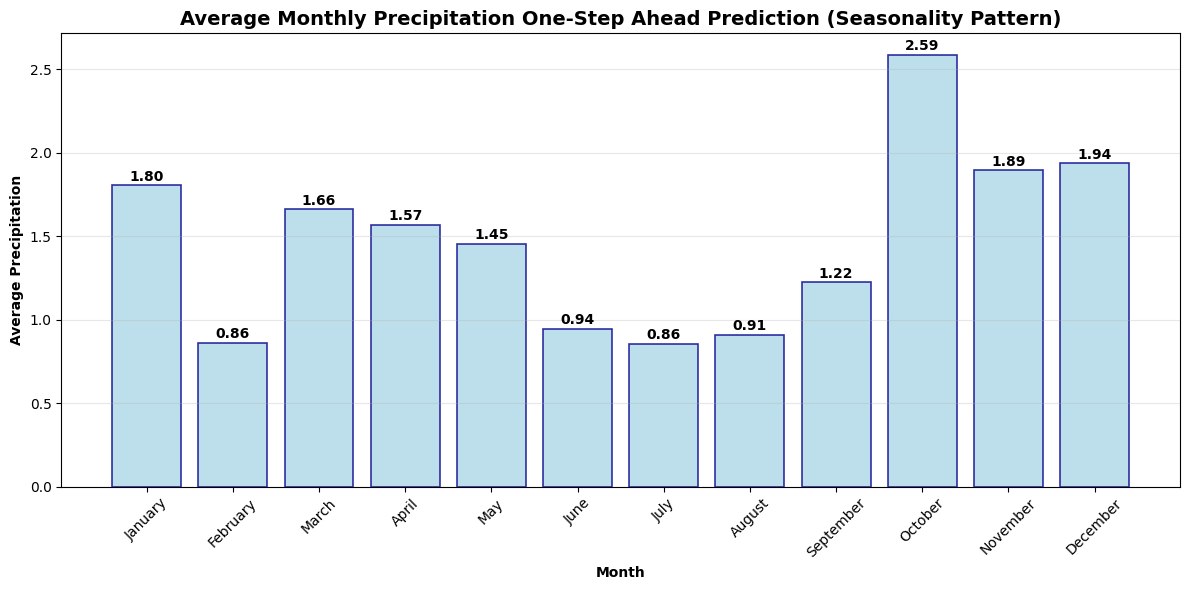

In [27]:
# Calculate monthly averages
monthly_avg = y_fit.groupby(y_fit.index.month)['gamma'].mean()

# Plot with month names
import calendar
month_names = [calendar.month_name[i] for i in monthly_avg.index]

plt.figure(figsize=(12, 6))
bars = plt.bar(month_names, monthly_avg.values, color='lightblue', edgecolor='darkblue', linewidth=1.2, alpha=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('Average Monthly Precipitation One-Step Ahead Prediction (Seasonality Pattern)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Average Precipitation', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Simulation

In [2]:
y = Simulator().simulate(1825, 20, 365.25, seed=42)

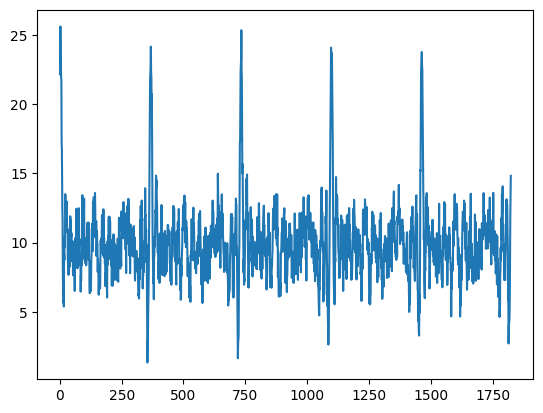

In [3]:
plt.plot(y)

In [4]:
# Create dynamics object
dynamics = Dynamics(
    distribution=GB2LogLinkDistribution(),
    n=len(y),
    trend=None,
    seasonality=None,
    harmonics=20,
    period=365.25,
    time_varying_indices=[0],
    fixed_params_indices=[1],
    args=[0.05, 0.02]
)


In [5]:
initial_params = dynamics.get_initial_values(y)

Initial parameter check:
km: 20 (bounds: 1-2000) - OK
kg: 20 (bounds: 1-2000) - OK
gamma_0: 0.0 (bounds: -200-200) - OK
mu0: 10 (bounds: -1000-1000) - OK
gamma_: 20 (bounds: 10-500) - OK
xi: 200 (bounds: 10-500) - OK
zeta: 200 (bounds: 20-1000) - OK
zeta > gamma_: True - OK


In [ ]:
bounds = [
    # km, kg - learning rates (will be divided by 1000)
    (-2000, 2000),      # km: results in 0.001 to 2.0 after scaling
    (-2000, 2000),      # kg: results in 0.001 to 2.0 after scaling
] + [
    # 40 seasonal parameters (20 gamma + 20 gamma_star)
    (-200, 200) for _ in range(40)
] + [
    # 6 distribution parameters
    (-1000, 1000),  # mu0: results in -10.0 to 10.0 after scaling
    # (-2000, 2000),    # delta_0: results in -2.0 to 2.0 after scaling  
    # (-1000, 1000),    # delta_1: results in -1.0 to 1.0 after scaling
    (1, 10000),      # gamma_: results in 0.1 to 5.0 after scaling (must be > 0)
    (0, 10000),      # xi: results in 0.1 to 5.0 after scaling (must be > 0)
    (1.2, 10000)      # zeta: results in 0.2 to 10.0 after scaling (must be > gamma_)
]

result = minimize(
    dynamics.objective,
    x0=initial_params,
    args=(y, bounds),
    method='BFGS',
    options={
        'gtol': 1e-1,
        'maxiter': 100,
        'disp': True
    }
)

c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


         Current function value: 10.813416
         Iterations: 5
         Function evaluations: 758
         Gradient evaluations: 16


c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


In [25]:
result

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 10.813415940926955
        x: [ 2.806e+01  1.528e+01 ...  8.127e+00  1.748e+02]
      nit: 5
      jac: [-1.262e-03 -2.193e-03 ...  8.426e-03  5.903e-02]
 hess_inv: [[ 8.708e+00 -4.491e+00 ... -1.833e+02 -2.445e+01]
            [-4.491e+00  3.617e+00 ...  1.068e+02  1.424e+01]
            ...
            [-1.833e+02  1.068e+02 ...  4.362e+03  5.815e+02]
            [-2.445e+01  1.424e+01 ...  5.815e+02  7.854e+01]]
     nfev: 758
     njev: 16

In [38]:
result['x']

array([ 2.80603526e+01,  1.52841444e+01,  8.92381242e-01,  8.77681901e-01,
        8.77689821e-01,  8.79225869e-01,  8.68799548e-01,  8.64872749e-01,
        8.58653626e-01,  8.67428626e-01,  8.61209379e-01,  8.63631709e-01,
        8.69290093e-01,  8.55714022e-01,  8.61495798e-01,  8.50259204e-01,
        8.62023743e-01,  8.52433054e-01,  8.51391515e-01,  8.38418762e-01,
        8.42502815e-01,  8.43864345e-01,  4.64043503e-03,  7.75537347e-03,
        5.21986178e-03, -1.77578335e-03, -4.10001006e-03,  5.24751345e-03,
       -4.10129022e-03, -1.71803646e-03,  5.76137287e-03, -8.99624632e-03,
        4.50844293e-03, -5.62844154e-03, -2.02784961e-03, -1.73411421e-02,
       -1.19241421e-03, -1.12684433e-03,  8.77068145e-03, -4.82591583e-03,
       -2.19859723e-03, -1.38561583e-02,  1.15072178e+01,  1.42426244e+01,
        8.12688661e+00,  1.74797257e+02])

In [8]:
y_fit = dynamics.fit_in_sample(result['x'], y)

TypeError: cannot unpack non-iterable numpy.float64 object

In [26]:
def fit_in_sample(params, y):
    gamma = np.zeros(20)
    gamma_star = np.zeros(20)

    km = params[0] / 1000
    kg = params[1] / 1000

    for i in range(20):
        gamma[i] = params[i + 2] / 100
        gamma_star[i] = params[i + 2 + 20] / 100

    mu0 = params[20 * 2 + 2] / 100
    # delta_0 = params[20 * 2 + 3] / 100
    # delta_1 = params[20 * 2 + 4] / 100
    # gamma_ = params[20 * 2 + 5] / 100
    # xi = params[20 * 2 + 6] / 100
    # zeta = params[20 * 2 + 7] / 100

    gamma_ = params[20 * 2 + 3] / 100
    xi = params[20 * 2 + 4] / 100
    zeta = params[20 * 2 + 5] / 100

    mu = mu0
    fit_in_sample = np.zeros(len(y))
    phis = np.zeros(len(y))
    
    for t in range(len(y)):
        phi = mu + np.sum(gamma)
        phis[t] = phi

        score = GB2LogLinkDistribution().score(
            y[t],
            # delta_0=delta_0,
            # delta_1=delta_1,
            phi=phi,
            gamma=gamma_,
            xi=xi,
            zeta=zeta,
        )[0]
        fit_in_sample[t] = GB2LogLinkDistribution().mean(
            # delta_0=delta_0,
            # delta_1=delta_1,
            phi=phi,
            gamma=gamma_,
            xi=xi,
            zeta=zeta,
        )
        mu += km * score
        # pi[t] = np.exp(delta_0 + delta_1 * phi) / (
        #     1 + np.exp(delta_0 + delta_1 * phi)
        # )

        for i in range(20):
            lambda_i = (2 * np.pi * (i + 1)) / 365.25
            gamma_t1 = (
                np.cos(lambda_i) * gamma[i]
                + np.sin(lambda_i) * gamma_star[i]
                + kg * score
            )
            gamma_start_t1 = (
                np.cos(lambda_i) * gamma_star[i]
                - np.sin(lambda_i) * gamma[i]
                + kg * score
            )
            gamma[i] = gamma_t1
            gamma_star[i] = gamma_start_t1

    return fit_in_sample, phis, gamma_, xi, zeta

In [27]:
y_fit, phis, gamma_, xi, zeta = fit_in_sample(result['x'], y)

In [28]:
zeta

np.float64(1.7479725700526538)

In [29]:
 GB2LogLinkDistribution().mean(
            # delta_0=delta_0,
            # delta_1=delta_1,
            phi=phis[10],
            gamma=gamma_,
            xi=xi,
            zeta=2.0,
        )

np.float64(4.714991621758234)

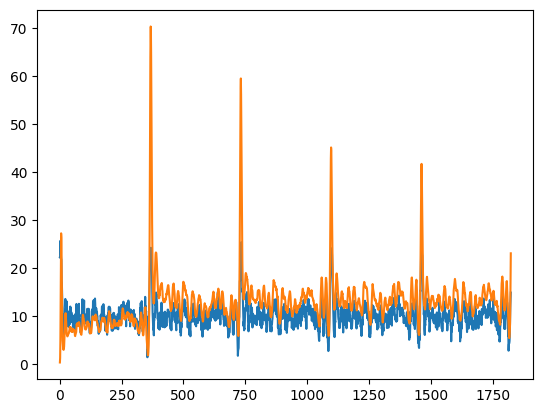

In [30]:
plt.plot(y)
plt.plot(y_fit)

In [31]:
def cdf(y, phi, gamma, xi, zeta):
    # Correct parameter mapping based on your specification:
    a = np.exp(-gamma)  # a = exp(-f2) where f2 is gamma
    b = np.exp(phi)     # b = exp(phi)
    p = xi              # p = xi (directly)
    q = zeta            # q = zeta (directly)
    
    # GB2 CDF: F(y) = I_{z/(1+z)}(a, b) where z = (y/b)^p
    # Note: In standard GB2 notation, the scale parameter is typically 'b'
    z = (y / b) ** p
    
    # Regularize to avoid numerical issues
    z = np.maximum(z, 1e-16)  # Ensure positive
    u = z / (1 + z)
    u = np.clip(u, 1e-16, 1 - 1e-16)  # Keep within (0,1) for betainc
    
    gb2_cdf = betainc(a, q, u)  # Note: using 'q' as the second parameter
    
    return gb2_cdf

In [32]:
pit = dynamics.pit(result['x'], y)

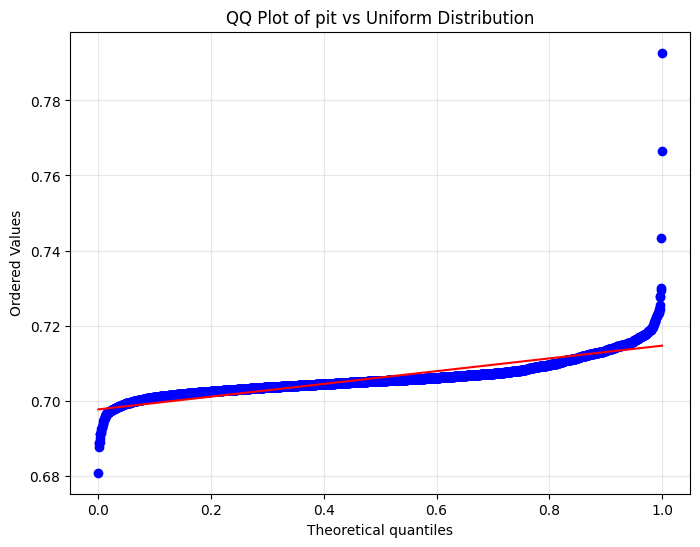

In [33]:
# Create QQ plot
plt.figure(figsize=(8, 6))
stats.probplot(pit, dist="uniform", plot=plt)
plt.title('QQ Plot of pit vs Uniform Distribution')
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
quant = dynamics.get_quantile_residuals(pit)

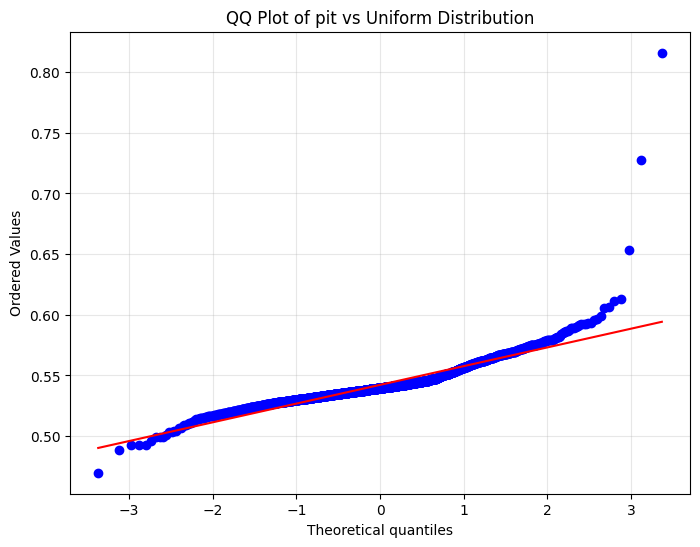

In [35]:
# Create QQ plot
plt.figure(figsize=(8, 6))
stats.probplot(quant, dist="norm", plot=plt)
plt.title('QQ Plot of pit vs Uniform Distribution')
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
phis

array([0.28746186, 1.78719804, 3.17641425, ..., 4.09029711, 4.44379754,
       4.74994945], shape=(1825,))

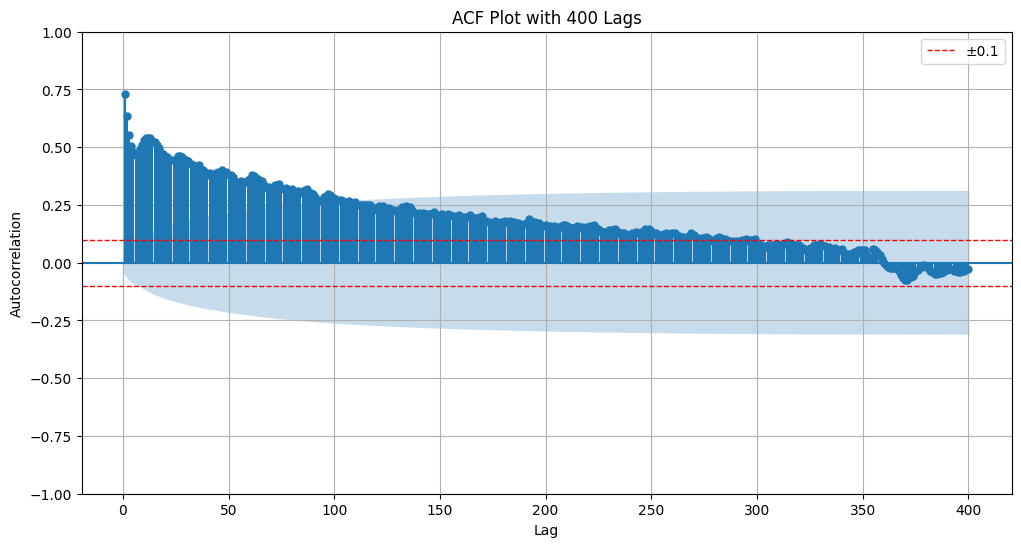

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Assuming 'quant' is your time series data
fig, ax = plt.subplots(figsize=(12, 6))

# Plot ACF without lag 0 by starting from lag 1
plot_acf(pit, lags=400, ax=ax, alpha=0.05, zero=False)

# Add red horizontal lines at -0.1 and 0.1
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='±0.1')
ax.axhline(y=-0.1, color='red', linestyle='--', linewidth=1)

plt.title('ACF Plot with 400 Lags')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()
plt.show()

In [21]:
erro = []
for t,_ in enumerate(y):
    erro.append((y[t] - y_fit[t])/GB2LogLinkDistribution().variance(
        phi = phis[t],
        gamma = gamma_,
        xi = xi,
        zeta = zeta
    ))

In [22]:
erro

[np.float64(36.98156547299431),
 np.float64(0.5100178019962361),
 np.float64(-0.0014793498201008319),
 np.float64(-0.014057322594553168),
 np.float64(-0.014503079751526099),
 np.float64(-0.01329048397485575),
 np.float64(-0.004389245503719134),
 np.float64(-0.005830905685634112),
 np.float64(0.02133941011625852),
 np.float64(0.018937542037524506),
 np.float64(0.025293381450546163),
 np.float64(0.03294562001101274),
 np.float64(-0.025432429248991667),
 np.float64(-0.014807086969960801),
 np.float64(-0.01701840678727603),
 np.float64(0.012232583964554752),
 np.float64(-0.018749125643744438),
 np.float64(0.1247534052977436),
 np.float64(-0.0089977295600397),
 np.float64(-0.0040756025257572956),
 np.float64(-0.024542377860114442),
 np.float64(1.3285875062953041e-05),
 np.float64(0.0013901054634202117),
 np.float64(-0.01445342436727933),
 np.float64(-0.0043888592717459445),
 np.float64(-0.003969670168252648),
 np.float64(0.00895018387680522),
 np.float64(0.007089157941125278),
 np.float64(0

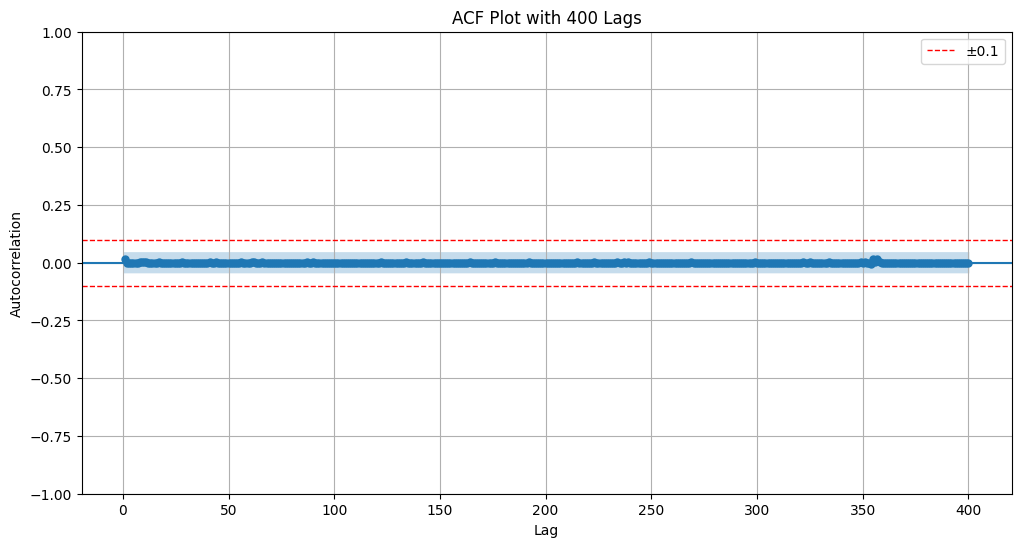

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Assuming 'quant' is your time series data
fig, ax = plt.subplots(figsize=(12, 6))

# Plot ACF without lag 0 by starting from lag 1
plot_acf(erro, lags=400, ax=ax, alpha=0.05, zero=False)

# Add red horizontal lines at -0.1 and 0.1
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='±0.1')
ax.axhline(y=-0.1, color='red', linestyle='--', linewidth=1)

plt.title('ACF Plot with 400 Lags')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()
plt.show()